### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importar los datos del dataset
df = pd.read_csv('data/drugLibTrain_raw.tsv', sep="\t", index_col=0)
df

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above
...,...,...,...,...,...,...,...,...
1039,vyvanse,10,Highly Effective,Mild Side Effects,adhd,"Increased focus, attention, productivity. Bett...","Restless legs at night, insomnia, headache (so...","I took adderall once as a child, and it made m..."
3281,zoloft,1,Ineffective,Extremely Severe Side Effects,depression,Emotions were somewhat blunted. Less moodiness.,"Weight gain, extreme tiredness during the day,...",I was on Zoloft for about 2 years total. I am ...
1664,climara,2,Marginally Effective,Moderate Side Effects,total hysterctomy,---,Constant issues with the patch not staying on....,---
2621,trileptal,8,Considerably Effective,Mild Side Effects,epilepsy,Controlled complex partial seizures.,"Dizziness, fatigue, nausea",Started at 2 doses of 300 mg a day and worked ...


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [3]:
# Mirar tipo de datos , si hay nulos o no...
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3107 entries, 2202 to 2748
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   urlDrugName        3107 non-null   object
 1   rating             3107 non-null   int64 
 2   effectiveness      3107 non-null   object
 3   sideEffects        3107 non-null   object
 4   condition          3106 non-null   object
 5   benefitsReview     3089 non-null   object
 6   sideEffectsReview  3032 non-null   object
 7   commentsReview     3095 non-null   object
dtypes: int64(1), object(7)
memory usage: 218.5+ KB


In [4]:
# Análisis descriptivo
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
urlDrugName,3107,502,lexapro,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,3107.0,NaN,NaN,NaN,7.006115,2.937582,1.0,5.0,8.0,9.0,10.0
effectiveness,3107,5,Highly Effective,1330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffects,3107,5,Mild Side Effects,1019,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,3106,1426,depression,236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefitsReview,3089,3031,none,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sideEffectsReview,3032,2813,none,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commentsReview,3095,3046,none,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Mirar columnas para ver con cual me quedo:
for column in df.columns:
    print(df[column].nunique())
    
# Como numérica me quedo con rating, y de las tipo object (categóricas), con effectiveness y 
# sideEffects que tienen menos de 10 categorías

502
10
5
5
1426
3031
2813
3046


In [6]:
# Categorias en efectiveness (5)
df['effectiveness'].unique()

array(['Highly Effective', 'Marginally Effective', 'Ineffective',
       'Considerably Effective', 'Moderately Effective'], dtype=object)

In [7]:
# Categorías de sideEffects (5)
df['sideEffects'].unique()

array(['Mild Side Effects', 'Severe Side Effects', 'No Side Effects',
       'Extremely Severe Side Effects', 'Moderate Side Effects'],
      dtype=object)

#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [8]:
# Hacer copia del dataframe para no perder el original:
df2=df.copy()

In [9]:
# Me quedo solo con las columnas que me interesan
df2 = df2[["effectiveness","sideEffects","rating"]]
df2

,effectiveness,sideEffects,rating
2202,Highly Effective,Mild Side Effects,4
3117,Highly Effective,Severe Side Effects,1
1146,Highly Effective,No Side Effects,10
3947,Marginally Effective,Mild Side Effects,3
1951,Marginally Effective,Severe Side Effects,2
...,...,...,...
1039,Highly Effective,Mild Side Effects,10
3281,Ineffective,Extremely Severe Side Effects,1
1664,Marginally Effective,Moderate Side Effects,2
2621,Considerably Effective,Mild Side Effects,8


In [10]:
# Transformar las columnas categoricas a numericas mediante dummies:
df2 = pd.get_dummies(df2[["effectiveness","sideEffects","rating"]])
df2

,rating,effectiveness_Considerably Effective,effectiveness_Highly Effective,effectiveness_Ineffective,effectiveness_Marginally Effective,effectiveness_Moderately Effective,sideEffects_Extremely Severe Side Effects,sideEffects_Mild Side Effects,sideEffects_Moderate Side Effects,sideEffects_No Side Effects,sideEffects_Severe Side Effects
2202,4,False,True,False,False,False,False,True,False,False,False
3117,1,False,True,False,False,False,False,False,False,False,True
1146,10,False,True,False,False,False,False,False,False,True,False
3947,3,False,False,False,True,False,False,True,False,False,False
1951,2,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...
1039,10,False,True,False,False,False,False,True,False,False,False
3281,1,False,False,True,False,False,True,False,False,False,False
1664,2,False,False,False,True,False,False,False,True,False,False
2621,8,True,False,False,False,False,False,True,False,False,False


In [11]:
# Como los datos categóricos de este dataframe tienen un orden intrínseco no tiene mucho sentido transformar con dummies
# A continuación se hará la transformación mediante un label encoder

In [12]:
# Hago otra copia del dataframe...
df3=df.copy()

In [13]:
# Como los datos categóricos de este dataframe tienen un orden intrínseco, no tiene mucho sentido no darles un valor, así 
# que imprimo los valores únicos para después darles un valor de 0 al 4.
df3['effectiveness'].unique()

array(['Highly Effective', 'Marginally Effective', 'Ineffective',
       'Considerably Effective', 'Moderately Effective'], dtype=object)

In [14]:
# Transformar variable effectiveness usando label encoder:
orden_effectiveness = {
    "Ineffective": 0,
    "Marginally Effective": 1,
    "Moderately Effective": 2,
    "Considerably Effective": 3,
    "Highly Effective": 4
}
df3['effectiveness_int'] = df3['effectiveness'].map(orden_effectiveness)
df3.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,effectiveness_int
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",4
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",4
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,4
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,1
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,1


In [15]:
# Imprimo los valores únicos de sideEffects para después darles un valor de 0 al 4.
df['sideEffects'].unique()

array(['Mild Side Effects', 'Severe Side Effects', 'No Side Effects',
       'Extremely Severe Side Effects', 'Moderate Side Effects'],
      dtype=object)

In [16]:
# Transformar variable sideEffects usando label encoder:
orden_sideEffects = {
    "No Side Effects": 0,
    "Mild Side Effects": 1,
    "Moderate Side Effects": 2,
    "Severe Side Effects": 3,
    "Extremely Severe Side Effects": 4
}

df3['sideEffects_int'] = df3['sideEffects'].map(orden_sideEffects)
df3.head()

,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview,effectiveness_int,sideEffects_int
2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ...",4,1
3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest...",4,3
1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...,4,0
3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...,1,1
1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above,1,3


In [17]:
df3 = df3.drop(["urlDrugName", "condition", "benefitsReview", "sideEffectsReview", "commentsReview"], axis=1)
df3.head()

,rating,effectiveness,sideEffects,effectiveness_int,sideEffects_int
2202,4,Highly Effective,Mild Side Effects,4,1
3117,1,Highly Effective,Severe Side Effects,4,3
1146,10,Highly Effective,No Side Effects,4,0
3947,3,Marginally Effective,Mild Side Effects,1,1
1951,2,Marginally Effective,Severe Side Effects,1,3


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

#### Genera el K Means 

In [18]:
# Crear X con mis variables, y comprobar su shape
X = df3[['rating', "effectiveness_int", "sideEffects_int"]]

In [19]:
from sklearn.preprocessing import StandardScaler
# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
print(X.shape)

(3107, 3)
(3107, 3)


In [20]:
# Buscar mejor k con un bucle de k = 2 a k = 20
from sklearn.cluster import KMeans

kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(2, 20)]
kmeans_per_k

[KMeans(n_clusters=2, n_init=10, random_state=42),
 KMeans(n_clusters=3, n_init=10, random_state=42),
 KMeans(n_clusters=4, n_init=10, random_state=42),
 KMeans(n_clusters=5, n_init=10, random_state=42),
 KMeans(n_clusters=6, n_init=10, random_state=42),
 KMeans(n_clusters=7, n_init=10, random_state=42),
 KMeans(n_init=10, random_state=42),
 KMeans(n_clusters=9, n_init=10, random_state=42),
 KMeans(n_clusters=10, n_init=10, random_state=42),
 KMeans(n_clusters=11, n_init=10, random_state=42),
 KMeans(n_clusters=12, n_init=10, random_state=42),
 KMeans(n_clusters=13, n_init=10, random_state=42),
 KMeans(n_clusters=14, n_init=10, random_state=42),
 KMeans(n_clusters=15, n_init=10, random_state=42),
 KMeans(n_clusters=16, n_init=10, random_state=42),
 KMeans(n_clusters=17, n_init=10, random_state=42),
 KMeans(n_clusters=18, n_init=10, random_state=42),
 KMeans(n_clusters=19, n_init=10, random_state=42)]

In [21]:
# Silhouette score de mis modelos con k = 2 a k = 20
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k]
silhouette_scores

[0.6190969508782411,
 0.4541665291694327,
 0.416701237123931,
 0.4152173517501398,
 0.40776675491666886,
 0.4044764199227224,
 0.3887036746255966,
 0.4139468434587661,
 0.40740876245511143,
 0.4310097927318671,
 0.41912862408038365,
 0.45984445240995503,
 0.4448386290466004,
 0.4811118973055916,
 0.4695772796209039,
 0.4614925667067238,
 0.484789428962796,
 0.5129626063919009]

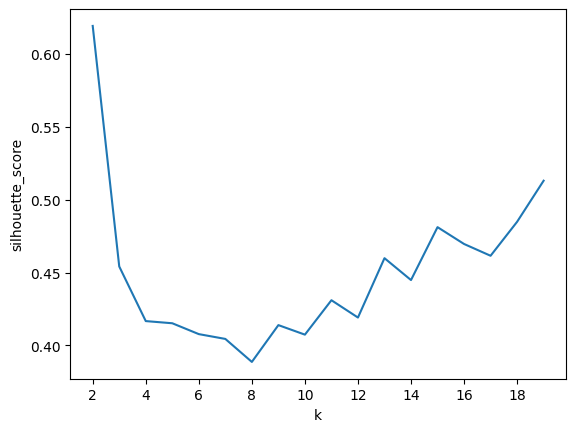

In [22]:
# Gráfica de mi sihouette scores:
plt.plot(range(2,20), silhouette_scores)
plt.xlabel("k")
plt.ylabel("silhouette_score");
plt.xticks(range(2,20,2));

# El codo está en k = 4?

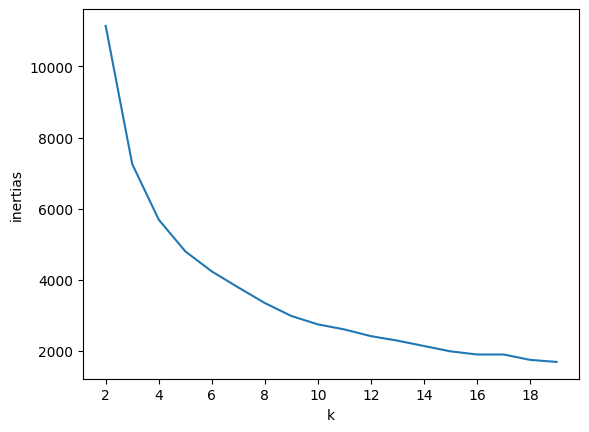

In [23]:
# Exploramos las inercias:
inertias = [model.inertia_ for model in kmeans_per_k]
plt.plot(range(2,20), inertias)
plt.xlabel("k")
plt.ylabel("inertias")
plt.xticks(range(2,20,2));

In [ ]:
# También alrededor de k = 4, me quedo con k = 4.

Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

In [52]:
kmeans_4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_scaled)
kmeans_4.labels_

array([0, 0, 2, ..., 1, 3, 1], shape=(3107,), dtype=int32)

In [53]:
# Guardar
df_cluster = X.copy()
df_cluster['cluster'] = kmeans_4.labels_
df_cluster

,rating,effectiveness_int,sideEffects_int,cluster
2202,4,4,1,0
3117,1,4,3,0
1146,10,4,0,2
3947,3,1,1,1
1951,2,1,3,1
...,...,...,...,...
1039,10,4,1,2
3281,1,0,4,1
1664,2,1,2,1
2621,8,3,1,3


In [54]:
df_cluster['cluster'].value_counts()

cluster
2    1077
3     815
0     695
1     520
Name: count, dtype: int64

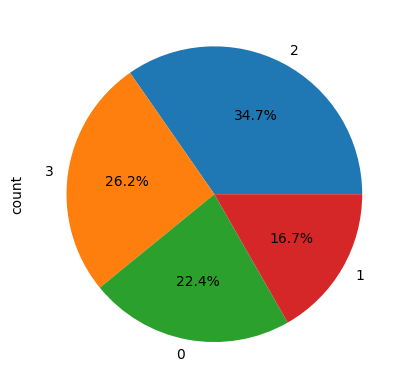

In [ ]:
# Pie Plot de mis clusters:
df_cluster['cluster'].value_counts().plot.pie(autopct="%.1f%%");